In [4]:
import pandas as pd

In [6]:
df=pd.read_csv('archive/DailyDelhiClimate.csv')

In [7]:
df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [8]:
df.set_index('date',inplace=True)

In [9]:
df.sample(3)

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2014-05-26,30.125000,54.125000,4.175000,1007.125000
2015-12-10,19.000000,77.250000,2.087500,1011.750000
2013-09-11,30.857143,61.142857,3.971429,1005.571429


In [12]:
df.shape

(1576, 4)

In [13]:
df.head()

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667
2013-01-02,7.400000,92.000000,2.980000,1017.800000
2013-01-03,7.166667,87.000000,4.633333,1018.666667
2013-01-04,8.666667,71.333333,1.233333,1017.166667
2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [14]:
df.tail()

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2017-04-20,34.500,27.500000,5.562500,998.625000
2017-04-21,34.250,39.375000,6.962500,999.875000
2017-04-22,32.900,40.900000,8.890000,1001.600000
2017-04-23,32.875,27.500000,9.962500,1002.125000
2017-04-24,32.000,27.142857,12.157143,1004.142857


In [10]:
temp = df['meantemp']

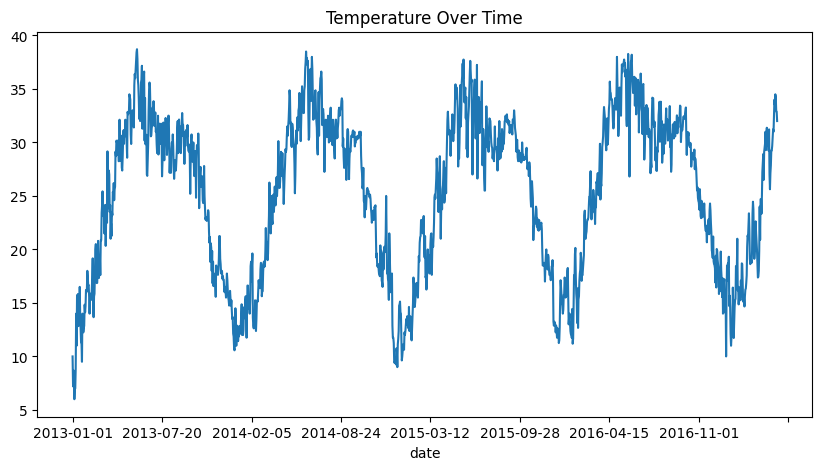

In [11]:
import matplotlib.pyplot as plt

temp.plot(figsize=(10,5), title="Temperature Over Time")
plt.show()

In [15]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(temp)
print("p-value:", result[1])

p-value: 0.14769623489792422


In [16]:
temp = temp.diff().dropna()

In [17]:
result = adfuller(temp)
print("p-value:", result[1])

p-value: 1.0140938123173498e-29


In [18]:
from statsmodels.tsa.ar_model import AutoReg

In [19]:

model = AutoReg(temp, lags=7)   # 7 days lag (weekly pattern)
model_fit = model.fit()

print(model_fit.summary())

                            AutoReg Model Results                             
Dep. Variable:               meantemp   No. Observations:                 1575
Model:                     AutoReg(7)   Log Likelihood               -2980.778
Method:               Conditional MLE   S.D. of innovations              1.619
Date:                Sun, 19 Apr 2026   AIC                           5979.555
Time:                        18:12:36   BIC                           6027.773
Sample:                             7   HQIC                          5997.478
                                 1575                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0287      0.041      0.702      0.483      -0.051       0.109
meantemp.L1    -0.2104      0.025     -8.345      0.000      -0.260      -0.161
meantemp.L2    -0.1512      0.026     -5.872    

C:\Users\Mcc\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [20]:
pred = model_fit.predict(start=len(temp), end=len(temp)+7)
print(pred)

1575    0.356645
1576    0.243098
1577    0.154616
1578    0.076860
1579    0.044336
1580   -0.033242
1581    0.003914
1582   -0.025905
dtype: float64


C:\Users\Mcc\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Mcc\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\Mcc\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


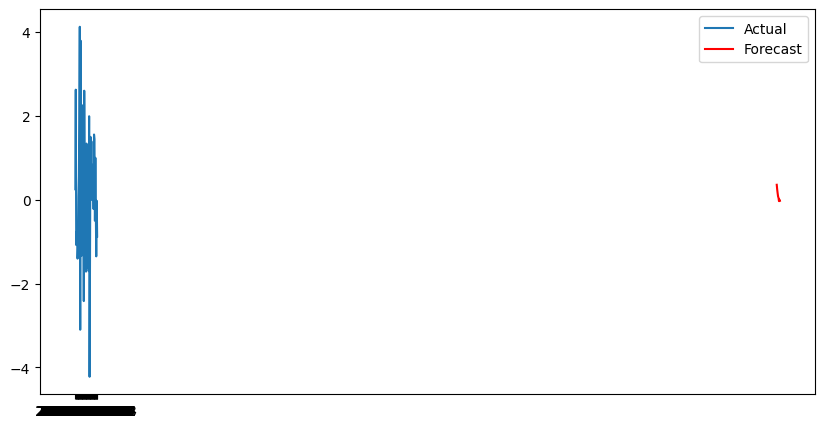

In [21]:
plt.figure(figsize=(10,5))
plt.plot(temp[-50:], label="Actual")
plt.plot(pred, label="Forecast", color='red')
plt.legend()
plt.show()

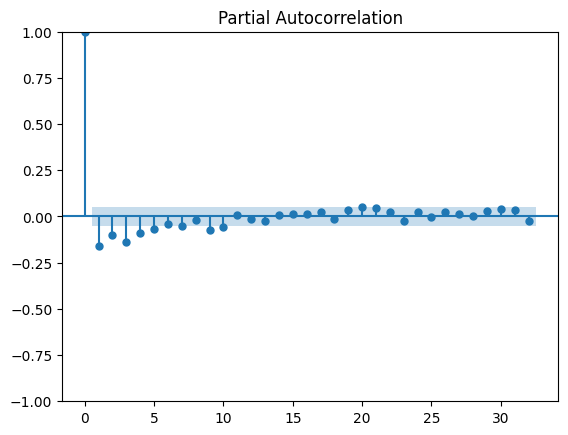

In [22]:
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(temp)
plt.show()